#  Speaker Diarization Pipeline
### CNN Embeddings → Transformer Encoder → Embeddings → Clustering


In [ ]:
import numpy as np
import pandas as pd
import random
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd

OUTPUT_ROOT = Path("/content/processed_data")
OUTPUT_ROOT.mkdir(exist_ok=True)

df_emb = pd.read_csv("/content/drive/MyDrive/cnn_embeddings_meta.csv")

print(f"Total windows:   {len(df_emb)}")
print(f"Silence rows:    {df_emb['speaker_id'].str.contains('silence').sum()}")
print(f"Speech rows:     {(~df_emb['speaker_id'].str.contains('silence')).sum()}")
print(f"Unique speakers: {df_emb['speaker_id'].nunique()}")
print(f"Meetings:        {df_emb['meeting'].nunique()}")
print(df_emb.head())

Mounted at /content/drive
Total windows:   19521
Silence rows:    957
Speech rows:     18564
Unique speakers: 48
Meetings:        10
   meeting  window_idx  start_time  end_time       speaker_id  \
0  EN2001a           0         0.0       3.0  EN2001a.silence   
1  EN2001a           1         1.5       4.5        EN2001a.E   
2  EN2001a           2         3.0       6.0        EN2001a.E   
3  EN2001a           3         4.5       7.5        EN2001a.E   
4  EN2001a           4         6.0       9.0        EN2001a.E   

                                            emb_path  
0  /content/processed_data/cnn_embeddings/EN2001a...  
1  /content/processed_data/cnn_embeddings/EN2001a...  
2  /content/processed_data/cnn_embeddings/EN2001a...  
3  /content/processed_data/cnn_embeddings/EN2001a...  
4  /content/processed_data/cnn_embeddings/EN2001a...  


In [ ]:
df_emb["emb_path"] = df_emb["emb_path"].apply(
    lambda p: str(Path("/content/drive/MyDrive/cnn_embeddings") / Path(p).name)
)

# verify
missing = df_emb[~df_emb["emb_path"].apply(lambda p: Path(p).exists())]
print(f"Missing files: {len(missing)}")
print(df_emb["emb_path"].head(3).tolist())

Missing files: 0
['/content/drive/MyDrive/cnn_embeddings/EN2001a_0.npy', '/content/drive/MyDrive/cnn_embeddings/EN2001a_1.npy', '/content/drive/MyDrive/cnn_embeddings/EN2001a_2.npy']


In [ ]:
train_meetings = ['EN2001a','EN2002a','EN2003a','EN2004a','EN2005a','EN2009b','IB4001']
val_meetings   = ['IN1001']
test_meetings  = ['IS1000a','TS3003a']
all_meetings   = train_meetings + val_meetings + test_meetings

df_train = df_emb[df_emb["meeting"].isin(train_meetings)].reset_index(drop=True)
df_val   = df_emb[df_emb["meeting"].isin(val_meetings)].reset_index(drop=True)
df_test  = df_emb[df_emb["meeting"].isin(test_meetings)].reset_index(drop=True)

print(f"Train: {len(df_train)} windows | {df_train['meeting'].nunique()} meetings")
print(f"Val:   {len(df_val)} windows   | {df_val['meeting'].nunique()} meetings")
print(f"Test:  {len(df_test)} windows  | {df_test['meeting'].nunique()} meetings")

# sanity check silence is present in all splits
for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    sil = df["speaker_id"].str.contains("silence").sum()
    print(f"  {name} silence rows: {sil}")

Train: 15157 windows | 7 meetings
Val:   2308 windows   | 1 meetings
Test:  2056 windows  | 2 meetings
  Train silence rows: 571
  Val silence rows: 88
  Test silence rows: 298


window_sec=3.0 — size of each individual CNN embedding chunk. Each .npy file represents 3 seconds of audio.

context_sec=30.0 — how much total audio the transformer sees at once. This is what you control.

In [ ]:
class TransformerDataset(Dataset):
    def __init__(self, df, context_sec=30.0, window_sec=3.0, hop_sec=15.0, seed=None):
        self.df      = df.sort_values(["meeting", "start_time"]).reset_index(drop=True)
        self.seq_len = int(context_sec / window_sec)
        self.hop     = int(hop_sec     / window_sec)
        self.rng     = random.Random(seed)
        self.sequences = self._build_sequences()
        print(f"  seq_len: {self.seq_len} steps ({context_sec}s) | hop: {self.hop} steps ({hop_sec}s) | total sequences: {len(self.sequences)}")

    def _build_sequences(self):
        sequences = []
        for meeting, group in self.df.groupby("meeting"):
            group = group.sort_values("start_time").reset_index(drop=True)
            for start in range(0, len(group) - self.seq_len + 1, self.hop):
                seq = group.iloc[start : start + self.seq_len]
                if len(seq) == self.seq_len:
                    sequences.append(seq.reset_index(drop=True))
        return sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # stack CNN embeddings → (seq_len, 256)
        embs = np.stack([np.load(row["emb_path"]) for _, row in seq.iterrows()])

        # local integer labels per sequence
        # silence gets its own label within the sequence
        speakers = seq["speaker_id"].values
        unique   = sorted(set(speakers))
        spk2idx  = {s: i for i, s in enumerate(unique)}
        labels   = np.array([spk2idx[s] for s in speakers], dtype=np.int64)

        return (
            torch.tensor(embs,   dtype=torch.float32),  # (10, 256)
            torch.tensor(labels, dtype=torch.long)       # (10,)
        )

# sanity check
ds    = TransformerDataset(df_train, seed=42)
embs, labels = ds[0]
print(f"Embedding shape: {embs.shape}")    #  (10, 256)
print(f"Labels shape:    {labels.shape}")  #  (10,)
print(f"Labels:          {labels.tolist()}")
print(f"Speakers in seq: {ds.sequences[0]['speaker_id'].tolist()}")

  seq_len: 10 steps (30.0s) | hop: 5 steps (15.0s) | total sequences: 3021
Embedding shape: torch.Size([10, 256])
Labels shape:    torch.Size([10])
Labels:          [2, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Speakers in seq: ['EN2001a.silence', 'EN2001a.E', 'EN2001a.E', 'EN2001a.E', 'EN2001a.E', 'EN2001a.E', 'EN2001a.A', 'EN2001a.A', 'EN2001a.A', 'EN2001a.A']


## Model — Speaker Transformer
> Refines CNN embeddings using self-attention over a 30s context window.  
> Output embeddings are L2-normalized for use with metric learning losses.

In [ ]:
class SpeakerTransformer(nn.Module):
    def __init__(self, input_dim=256, nhead=4, num_layers=2,
                 dim_feedforward=512, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, input_dim)
        self.pos_enc    = nn.Embedding(512, input_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(input_dim, input_dim)

    def forward(self, x):
        # x: (batch, seq_len, 256)
        B, T, D    = x.shape
        positions  = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        x = self.input_proj(x) + self.pos_enc(positions)
        x = self.transformer(x)
        return nn.functional.normalize(self.output_proj(x), p=2, dim=-1)
        # output: (batch, 10, 256) — one refined embedding per 3s step

# sanity check
model    = SpeakerTransformer().to(device)
dummy_in = torch.randn(4, 10, 256).to(device)
dummy_out = model(dummy_in)
print(f"Input shape:  {dummy_in.shape}")   # (4, 10, 256)
print(f"Output shape: {dummy_out.shape}")  # (4, 10, 256)
print(f"L2 norm:      {dummy_out.norm(dim=-1).mean().item():.4f}")  # should be ~1.0

Input shape:  torch.Size([4, 10, 256])
Output shape: torch.Size([4, 10, 256])
L2 norm:      1.0000


##  Loss — Sequence Triplet Loss
> For each anchor window, randomly samples one positive (same speaker) and one negative (different speaker) within the same sequence.  
> Encourages same-speaker embeddings to cluster and different-speaker embeddings to separate.

In [ ]:
def sequence_triplet_loss(embs, labels, margin=0.3):
    B, T, D = embs.shape

    diff = embs.unsqueeze(2) - embs.unsqueeze(1)
    dist = diff.norm(dim=-1)  # (B, T, T)

    labels_i  = labels.unsqueeze(2)
    labels_j  = labels.unsqueeze(1)
    same_mask = (labels_i == labels_j)
    diff_mask = ~same_mask
    eye       = torch.eye(T, device=embs.device).bool().unsqueeze(0)
    same_mask = same_mask & ~eye

    losses = []

    for b in range(B):
        for i in range(T):
            pos_indices = same_mask[b, i].nonzero(as_tuple=True)[0]
            neg_indices = diff_mask[b, i].nonzero(as_tuple=True)[0]

            if len(pos_indices) == 0 or len(neg_indices) == 0:
                continue

            pos_idx = pos_indices[torch.randint(len(pos_indices), (1,)).item()]
            neg_idx = neg_indices[torch.randint(len(neg_indices), (1,)).item()]

            triplet_loss = nn.functional.relu(
                dist[b, i, pos_idx] - dist[b, i, neg_idx] + margin
            )
            losses.append(triplet_loss)

    if len(losses) == 0:
        return torch.tensor(0.0, device=embs.device, requires_grad=True)

    return torch.stack(losses).mean()



##  Build DataLoaders

In [ ]:
train_dataset = TransformerDataset(df_train, seed=None)
val_dataset   = TransformerDataset(df_val,   seed=42)
test_dataset  = TransformerDataset(df_test,  seed=42)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

  seq_len: 10 steps (30.0s) | hop: 5 steps (15.0s) | total sequences: 3021
  seq_len: 10 steps (30.0s) | hop: 5 steps (15.0s) | total sequences: 460
  seq_len: 10 steps (30.0s) | hop: 5 steps (15.0s) | total sequences: 408
Train batches: 189
Val batches:   29
Test batches:  26


In [ ]:
from pathlib import Path
from tqdm import tqdm
import shutil

emb_local_dir = Path("/content/processed_data/cnn_embeddings")
emb_local_dir.mkdir(exist_ok=True)

emb_drive_dir = Path("/content/drive/MyDrive/cnn_embeddings")

print("Copying embeddings from Drive to local...")
for emb_file in tqdm(list(emb_drive_dir.glob("*.npy"))):
    dest = emb_local_dir / emb_file.name
    if not dest.exists():
        shutil.copy(emb_file, dest)

print(f"Done — {len(list(emb_local_dir.glob('*.npy')))} files ready")

# fix paths to local
df_emb["emb_path"] = df_emb["emb_path"].apply(
    lambda p: str(emb_local_dir / Path(p).name)
)

# rebuild splits
df_train = df_emb[df_emb["meeting"].isin(train_meetings)].reset_index(drop=True)
df_val   = df_emb[df_emb["meeting"].isin(val_meetings)].reset_index(drop=True)
df_test  = df_emb[df_emb["meeting"].isin(test_meetings)].reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Copying embeddings from Drive to local...


100%|██████████| 19521/19521 [1:04:53<00:00,  5.01it/s]


Done — 19521 files ready
Train: 15157 | Val: 2308 | Test: 2056


## Training
| Hyperparameter | Value |
|---|---|
| Epochs | 30 |
| Learning Rate | 0.0001 |
| Patience | 8 |
| Margin | 0.3 |
| Optimizer | Adam + weight decay 0.0001 |


In [ ]:
EPOCHS   = 30
LR       = 0.0001
PATIENCE = 8
MARGIN   = 0.3

transformer = SpeakerTransformer(
    input_dim=256, nhead=4, num_layers=2,
    dim_feedforward=512, dropout=0.3
).to(device)

optimizer = optim.Adam(transformer.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_losses, val_losses = [], []
best_val          = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    transformer.train()
    train_loss = 0.0

    for embs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        embs, labels = embs.to(device), labels.to(device)
        out  = transformer(embs)
        loss = sequence_triplet_loss(out, labels, margin=MARGIN)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    transformer.eval()
    val_loss = 0.0
    with torch.no_grad():
        for embs, labels in val_loader:
            embs, labels = embs.to(device), labels.to(device)
            out       = transformer(embs)
            val_loss += sequence_triplet_loss(out, labels, margin=MARGIN).item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    if avg_val < best_val:
        best_val          = avg_val
        epochs_no_improve = 0
        torch.save(transformer.state_dict(), "/content/drive/MyDrive/transformer_best.pth")
        print(f"Best model saved (val={best_val:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"\nBest val loss: {best_val:.4f}")

Epoch 1/30 [Train]: 100%|██████████| 189/189 [01:31<00:00,  2.08it/s]


Best model saved (val=0.2018)
Epoch 1/30 | Train: 0.2024 | Val: 0.2018 | LR: 0.000100


Epoch 2/30 [Train]: 100%|██████████| 189/189 [01:31<00:00,  2.07it/s]


Best model saved (val=0.2000)
Epoch 2/30 | Train: 0.1933 | Val: 0.2000 | LR: 0.000100


Epoch 3/30 [Train]: 100%|██████████| 189/189 [01:32<00:00,  2.05it/s]


...

Epoch 17/30 | Train: 0.1563 | Val: 0.1949 | LR: 0.000050


Epoch 18/30 [Train]: 100%|██████████| 189/189 [01:35<00:00,  1.97it/s]


Epoch 18/30 | Train: 0.1516 | Val: 0.1895 | LR: 0.000050


Epoch 19/30 [Train]: 100%|██████████| 189/189 [01:39<00:00,  1.90it/s]



Early stopping at epoch 19

Best val loss: 0.1863


Patience = 5 LR 0.0001 -> Best val loss: 0.1904

Patience = 8 LR 0.0001 -> Best val loss: 0.1863


##  Training Curves

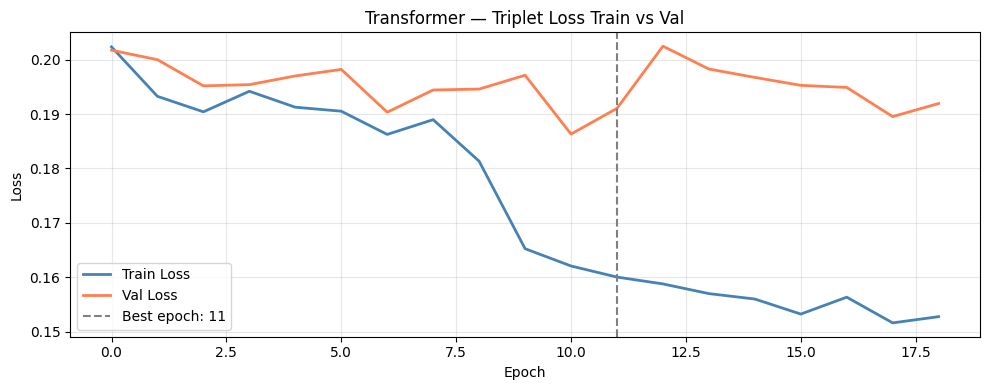

Best epoch: 11 | Best val loss: 0.1863


In [ ]:
best_ep = val_losses.index(min(val_losses)) + 1
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(val_losses,   label="Val Loss",   color="coral",     linewidth=2)
plt.axvline(best_ep, color="gray", linestyle="--", label=f"Best epoch: {best_ep}")
plt.title("Transformer — Triplet Loss Train vs Val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/content/drive/MyDrive/transformer_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best epoch: {best_ep} | Best val loss: {min(val_losses):.4f}")

##  UMAP Visualization — Transformer Embeddings
> Each subplot shows one meeting. Points are colored by speaker.  
> Well-separated clusters indicate the transformer has learned discriminative speaker embeddings.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


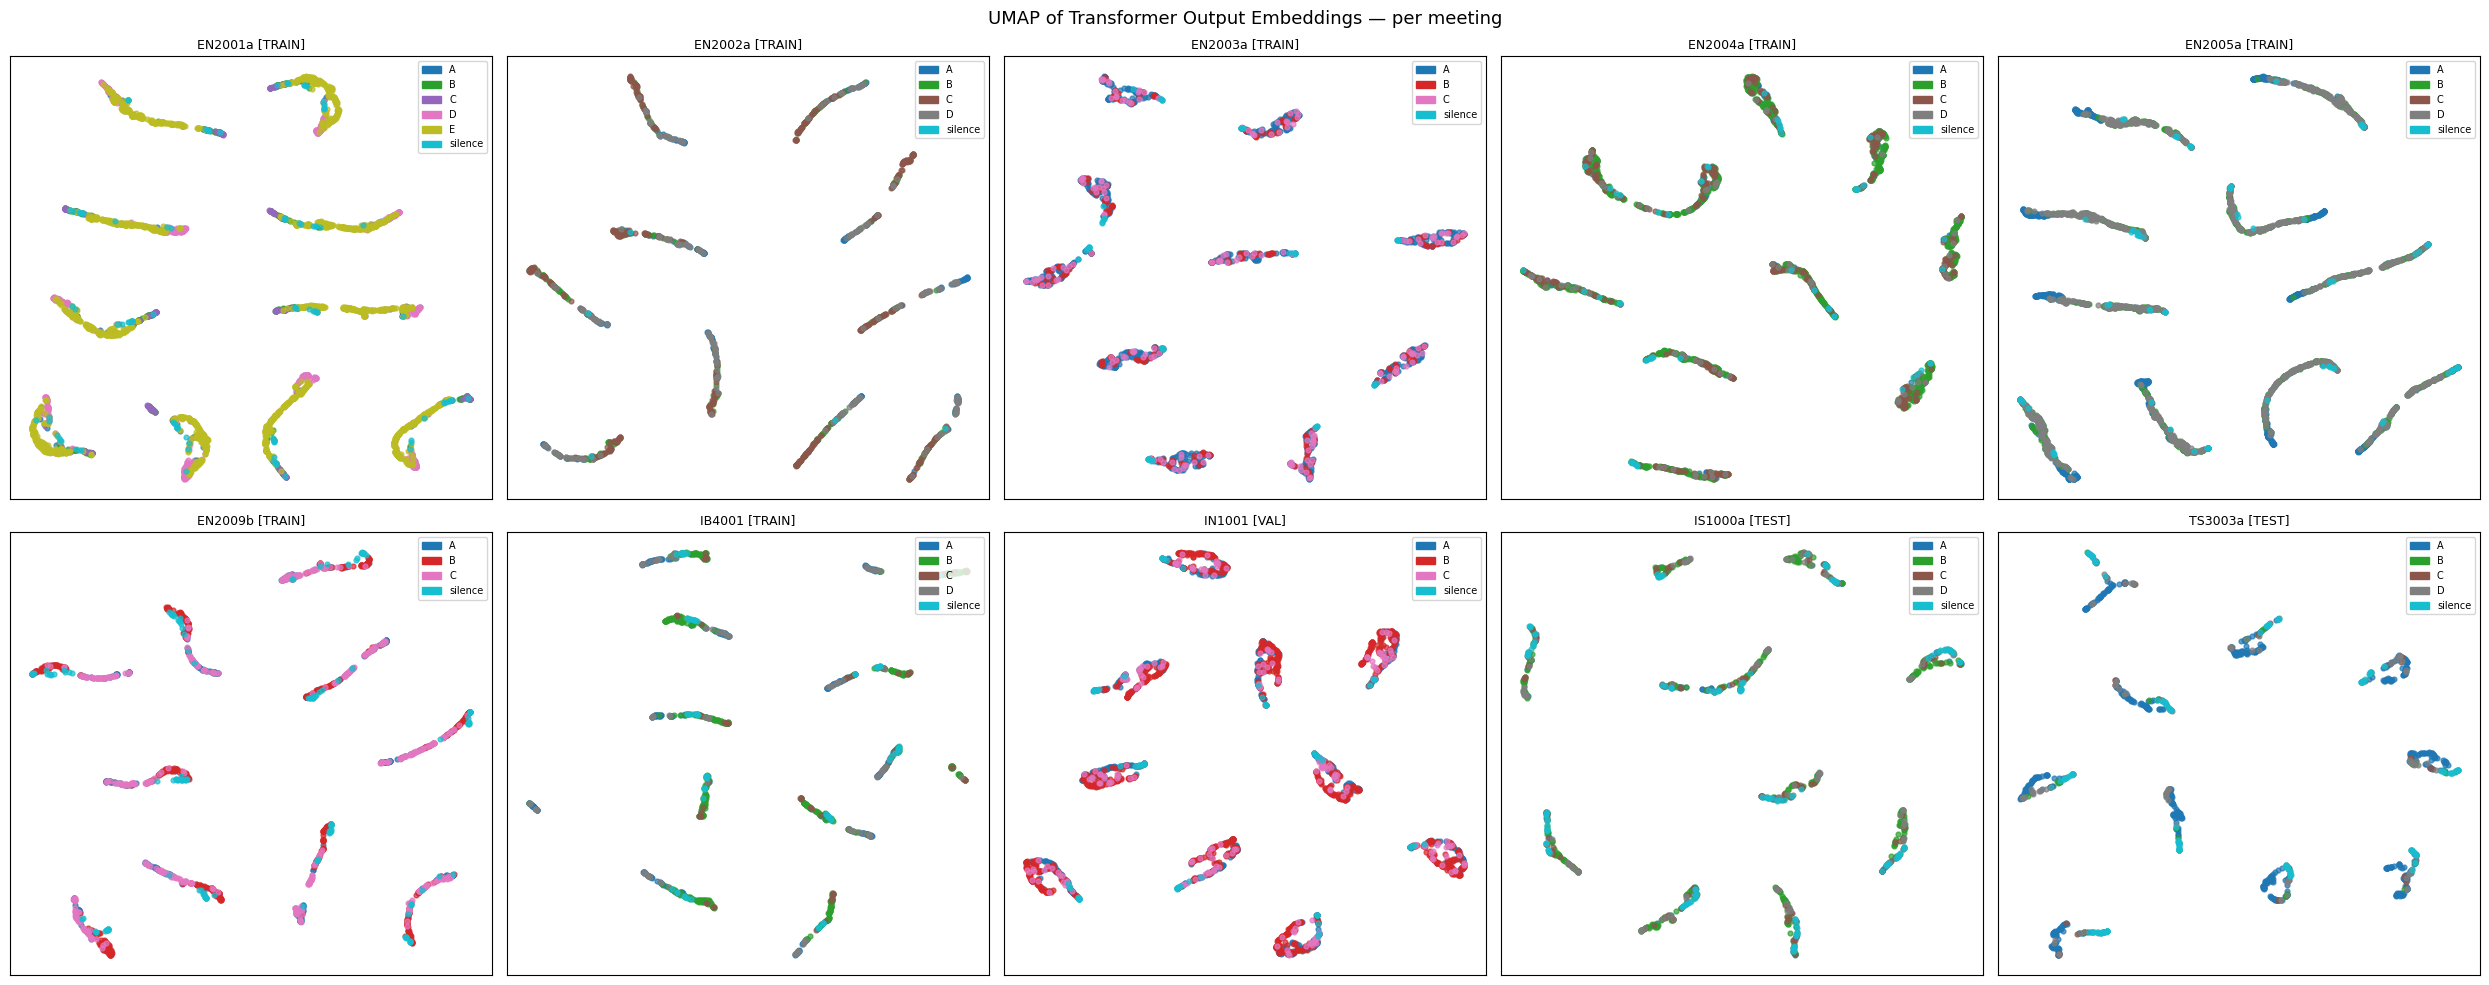

In [ ]:
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

transformer.load_state_dict(torch.load("/content/drive/MyDrive/transformer_best.pth"))
transformer.eval()

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for ax_idx, meeting in enumerate(all_meetings):
    subset = df_emb[df_emb["meeting"] == meeting].sort_values("start_time").reset_index(drop=True)

    if len(subset) < 10:
        axes[ax_idx].axis("off")
        continue

    # build non-overlapping sequences for this meeting
    seq_len = 10
    all_embs, all_labels = [], []

    for start in range(0, len(subset) - seq_len + 1, seq_len):
        seq = subset.iloc[start : start + seq_len]
        embs_np = np.stack([np.load(row["emb_path"]) for _, row in seq.iterrows()])
        embs_t  = torch.tensor(embs_np, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            out = transformer(embs_t).squeeze(0).cpu().numpy()  # (10, 256)

        all_embs.append(out)
        all_labels.extend(seq["speaker_id"].values)

    all_embs   = np.vstack(all_embs)   # (N, 256)
    all_labels = np.array(all_labels)

    proj = reducer.fit_transform(all_embs)

    unique_spks = sorted(set(all_labels))
    colors      = plt.cm.tab10(np.linspace(0, 1, len(unique_spks)))
    spk2color   = {s: c for s, c in zip(unique_spks, colors)}

    ax = axes[ax_idx]
    for spk in unique_spks:
        mask = all_labels == spk
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[spk2color[spk]], s=12, alpha=0.7,
                   label=spk.split(".")[-1])

    patches = [mpatches.Patch(color=spk2color[s], label=s.split(".")[-1]) for s in unique_spks]
    ax.legend(handles=patches, fontsize=7, loc="upper right")

    split = "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")
    ax.set_title(f"{meeting} [{split}]", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

for i in range(len(all_meetings), len(axes)):
    axes[i].axis("off")

plt.suptitle("UMAP of Transformer Output Embeddings — per meeting", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/umap_transformer.png", dpi=150, bbox_inches="tight")
plt.show()

## Clustering — Agglomerative + DER Evaluation
> Embeddings are clustered using Agglomerative Clustering
> DER (Diarization Error Rate) measures the fraction of non-silence windows assigned to the wrong speaker after optimal label alignment.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from scipy.optimize import linear_sum_assignment

In [ ]:
transformer.load_state_dict(torch.load("/content/drive/MyDrive/transformer_best.pth"))
transformer.eval()

meeting_embeddings = {}  # meeting → (N, 256) transformer embeddings
meeting_labels     = {}  # meeting → (N,) ground truth speaker_id strings

seq_len = 10

for meeting in tqdm(all_meetings, desc="Extracting transformer embeddings"):
    subset = df_emb[df_emb["meeting"] == meeting].sort_values("start_time").reset_index(drop=True)

    all_embs, all_labels = [], []

    for start in range(0, len(subset) - seq_len + 1, seq_len):
        seq     = subset.iloc[start : start + seq_len]
        embs_np = np.stack([np.load(row["emb_path"]) for _, row in seq.iterrows()])
        embs_t  = torch.tensor(embs_np, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            out = transformer(embs_t).squeeze(0).cpu().numpy()  # (10, 256)

        all_embs.append(out)
        all_labels.extend(seq["speaker_id"].values)

    meeting_embeddings[meeting] = normalize(np.vstack(all_embs), norm="l2")
    meeting_labels[meeting]     = np.array(all_labels)

    print(f"  {meeting}: {meeting_embeddings[meeting].shape[0]} windows, "
          f"{len(set(meeting_labels[meeting]))} unique labels")

Extracting transformer embeddings:  10%|█         | 1/10 [00:07<01:08,  7.56s/it]

  EN2001a: 3490 windows, 6 unique labels


Extracting transformer embeddings:  20%|██        | 2/10 [00:09<00:34,  4.31s/it]

  EN2002a: 1420 windows, 5 unique labels


Extracting transformer embeddings:  30%|███       | 3/10 [00:11<00:23,  3.41s/it]

...

  IN1001: 2300 windows, 4 unique labels


Extracting transformer embeddings:  90%|█████████ | 9/10 [00:22<00:01,  1.47s/it]

  IS1000a: 1050 windows, 5 unique labels


Extracting transformer embeddings: 100%|██████████| 10/10 [00:23<00:00,  2.36s/it]

  TS3003a: 1000 windows, 5 unique labels


In [ ]:
def estimate_n_speakers(embeddings, min_speakers=2, max_speakers=8):
    from sklearn.metrics import silhouette_score

    best_n     = min_speakers
    best_score = -1

    for n in range(min_speakers, max_speakers + 1):
        pred = AgglomerativeClustering(
            n_clusters=n, metric="cosine", linkage="average"
        ).fit_predict(embeddings)

        if len(set(pred)) < 2:
            continue

        score = silhouette_score(embeddings, pred, metric="cosine")
        if score > best_score:
            best_score = score
            best_n     = n

    return best_n, best_score


def cluster_meeting(embeddings, n_speakers):
    return AgglomerativeClustering(
        n_clusters=n_speakers, metric="cosine", linkage="average"
    ).fit_predict(embeddings)

In [ ]:
def compute_der(true_labels, pred_labels, window_sec=3.0):

    non_silence_mask = np.array(["silence" not in l for l in true_labels])

    true_clean = true_labels[non_silence_mask]
    pred_clean = pred_labels[non_silence_mask]

    if len(true_clean) == 0:
        return 1.0, 0, 0

    unique_true = sorted(set(true_clean))
    true_int    = np.array([unique_true.index(l) for l in true_clean])

    n_true = len(unique_true)
    n_pred = len(set(pred_clean))
    n      = max(n_true, n_pred)

    cost = np.zeros((n, n), dtype=np.int32)
    for t, p in zip(true_int, pred_clean):
        cost[t, p] += 1

    row_ind, col_ind = linear_sum_assignment(-cost)

    correct = cost[row_ind, col_ind].sum()
    total   = len(true_clean)

    confusion    = total - correct
    total_speech = total * window_sec
    der = confusion / total

    return der, confusion, total


print("DER function ready")

DER function ready


In [ ]:
cnn_meeting_embeddings = {}

for meeting in tqdm(all_meetings, desc="Extracting CNN embeddings"):
    subset = df_emb[df_emb["meeting"] == meeting].sort_values("start_time").reset_index(drop=True)

    seq_len  = 10
    n_blocks = len(subset) // seq_len * seq_len
    subset   = subset.iloc[:n_blocks].reset_index(drop=True)

    embs = np.stack([np.load(row["emb_path"]) for _, row in subset.iterrows()])
    cnn_meeting_embeddings[meeting] = normalize(embs, norm="l2")

results = []

print(f"\n{'Meeting':<12} {'Split':<6} {'True N':<8} {'Est N (T)':<10} {'Est N (C)':<10} {'DER CNN':<10} {'DER Trans':<10}")
print("-" * 70)

for meeting in all_meetings:
    true_labels  = meeting_labels[meeting]
    trans_embs   = meeting_embeddings[meeting]
    cnn_embs     = cnn_meeting_embeddings[meeting]

    # true number of speakers (excluding silence)
    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    # estimate n_speakers separately for CNN and transformer
    n_est_trans, _ = estimate_n_speakers(trans_embs, min_speakers=2, max_speakers=n_true+2)
    n_est_cnn,   _ = estimate_n_speakers(cnn_embs,   min_speakers=2, max_speakers=n_true+2)

    # cluster
    pred_trans = cluster_meeting(trans_embs, n_est_trans)
    pred_cnn   = cluster_meeting(cnn_embs,   n_est_cnn)

    # DER
    der_trans, conf_t, total = compute_der(true_labels, pred_trans)
    der_cnn,   conf_c, _     = compute_der(true_labels, pred_cnn)

    split = "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")

    print(f"{meeting:<12} {split:<6} {n_true:<8} {n_est_trans:<10} {n_est_cnn:<10} "
          f"{der_cnn*100:<10.1f} {der_trans*100:<10.1f}")

    results.append({
        "meeting":      meeting,
        "split":        split,
        "n_true":       n_true,
        "n_est_trans":  n_est_trans,
        "n_est_cnn":    n_est_cnn,
        "der_cnn":      der_cnn,
        "der_trans":    der_trans,
    })

df_results = pd.DataFrame(results)

print("\n── Summary ───────────────────")
for split in ["TRAIN", "VAL", "TEST"]:
    sub = df_results[df_results["split"] == split]
    if len(sub) == 0:
        continue
    print(f"{split}  | CNN DER: {sub['der_cnn'].mean()*100:.1f}%  "
          f"Transformer DER: {sub['der_trans'].mean()*100:.1f}%")

print(f"\nOVERALL | CNN DER: {df_results['der_cnn'].mean()*100:.1f}%  "
      f"Transformer DER: {df_results['der_trans'].mean()*100:.1f}%")

Extracting CNN embeddings: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]



Meeting      Split  True N   Est N (T)  Est N (C)  DER CNN    DER Trans 
----------------------------------------------------------------------
EN2001a      TRAIN  5        3          4          26.5       50.0      
EN2002a      TRAIN  4        2          2          47.1       48.1      
EN2003a      TRAIN  3        2          2          28.2       29.1      
EN2004a      TRAIN  4        2          2          35.6       33.5      
EN2005a      TRAIN  4        4          3          49.5       59.6      
EN2009b      TRAIN  3        4          3          39.2       54.4      
IB4001       TRAIN  4        6          2          37.2       63.3      
IN1001       VAL    3        3          2          47.7       56.7      
IS1000a      TEST   4        5          2          43.2       74.3      
TS3003a      TEST   4        6          2          33.6       71.3      

── Summary ───────────────────
TRAIN  | CNN DER: 37.6%  Transformer DER: 48.3%
VAL  | CNN DER: 47.7%  Transformer DER: 56.7%

In [ ]:
def smooth_embeddings(embs, window=5):

    smoothed = np.zeros_like(embs)
    for i in range(len(embs)):
        start = max(0, i - window // 2)
        end   = min(len(embs), i + window // 2 + 1)
        smoothed[i] = embs[start:end].mean(axis=0)
    return normalize(smoothed, norm="l2")

##  Temporal Smoothing
> A sliding window average smooths embeddings over time before clustering.  
> This reduces noise from brief speaker changes and transient artifacts.

In [ ]:
print(f"\n{'Meeting':<12} {'Split':<6} {'DER CNN':<10} {'DER Trans':<12} {'DER Trans Smooth'}")
print("-" * 65)

results_smooth = []

for meeting in all_meetings:
    true_labels = meeting_labels[meeting]
    trans_embs  = meeting_embeddings[meeting]
    cnn_embs    = cnn_meeting_embeddings[meeting]

    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    # smooth transformer embeddings
    smoothed = smooth_embeddings(trans_embs, window=5)

    pred_cnn    = cluster_meeting(cnn_embs,   n_true)
    pred_trans  = cluster_meeting(trans_embs, n_true)
    pred_smooth = cluster_meeting(smoothed,   n_true)

    der_cnn,    _, _ = compute_der(true_labels, pred_cnn)
    der_trans,  _, _ = compute_der(true_labels, pred_trans)
    der_smooth, _, _ = compute_der(true_labels, pred_smooth)

    split = "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")
    print(f"{meeting:<12} {split:<6} {der_cnn*100:<10.1f} {der_trans*100:<12.1f} {der_smooth*100:.1f}")

    results_smooth.append({
        "meeting":    meeting,
        "split":      split,
        "der_cnn":    der_cnn,
        "der_trans":  der_trans,
        "der_smooth": der_smooth,
    })

df_smooth = pd.DataFrame(results_smooth)

print("\n── Smoothed Summary ─────────────────────────────────────")
for split in ["TRAIN", "VAL", "TEST"]:
    sub = df_smooth[df_smooth["split"] == split]
    if len(sub) == 0:
        continue
    print(f"{split}  | CNN: {sub['der_cnn'].mean()*100:.1f}%  "
          f"Trans: {sub['der_trans'].mean()*100:.1f}%  "
          f"Trans+Smooth: {sub['der_smooth'].mean()*100:.1f}%")

print(f"\nOVERALL | CNN: {df_smooth['der_cnn'].mean()*100:.1f}%  "
      f"Trans: {df_smooth['der_trans'].mean()*100:.1f}%  "
      f"Trans+Smooth: {df_smooth['der_smooth'].mean()*100:.1f}%")


Meeting      Split  DER CNN    DER Trans    DER Trans Smooth
-----------------------------------------------------------------
EN2001a      TRAIN  26.5       55.8         57.1
EN2002a      TRAIN  47.0       53.7         48.6
EN2003a      TRAIN  30.4       35.4         28.2
EN2004a      TRAIN  35.7       43.8         55.0
EN2005a      TRAIN  48.9       59.6         42.9
EN2009b      TRAIN  39.2       51.5         35.0
IB4001       TRAIN  46.8       46.0         40.6
IN1001       VAL    51.6       56.7         50.0
IS1000a      TEST   51.2       71.0         60.0
TS3003a      TEST   37.5       63.4         52.0

── Smoothed Summary ─────────────────────────────────────
TRAIN  | CNN: 39.2%  Trans: 49.4%  Trans+Smooth: 43.9%
VAL  | CNN: 51.6%  Trans: 56.7%  Trans+Smooth: 50.0%
TEST  | CNN: 44.4%  Trans: 67.2%  Trans+Smooth: 56.0%

OVERALL | CNN: 41.5%  Trans: 53.7%  Trans+Smooth: 46.9%


In [ ]:
df_smooth.to_csv("/content/drive/MyDrive/final_results.csv", index=False)
print("Results saved to Drive")

Results saved to Drive


##  DER Comparison — CNN vs Transformer vs Transformer+Smooth

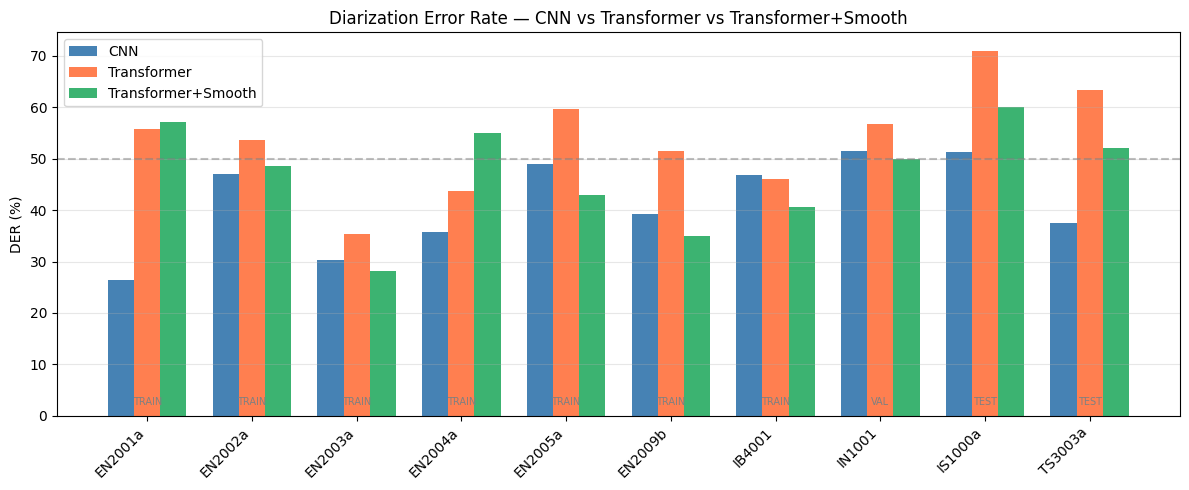

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(all_meetings))
width  = 0.25

bars1 = ax.bar(x - width, df_smooth["der_cnn"]    * 100, width, label="CNN",              color="steelblue")
bars2 = ax.bar(x,          df_smooth["der_trans"]  * 100, width, label="Transformer",      color="coral")
bars3 = ax.bar(x + width,  df_smooth["der_smooth"] * 100, width, label="Transformer+Smooth", color="mediumseagreen")

ax.set_xticks(x)
ax.set_xticklabels(all_meetings, rotation=45, ha="right")
ax.set_ylabel("DER (%)")
ax.set_title("Diarization Error Rate — CNN vs Transformer vs Transformer+Smooth")
ax.legend()
ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% baseline")
ax.grid(True, alpha=0.3, axis="y")

# add split labels
for i, (meeting, row) in enumerate(df_smooth.iterrows()):
    split = "TRAIN" if all_meetings[i] in train_meetings else ("VAL" if all_meetings[i] in val_meetings else "TEST")
    ax.text(i, 2, split, ha="center", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/der_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

##Top 3 Meetings Where Transformer Wins
> Side-by-side UMAP: raw CNN clusters vs Transformer+Smooth clusters.

Top 3 meetings where Transformer+Smooth beats CNN:
  IB4001: CNN=46.8%  Trans+Smooth=40.6%  improvement=6.2%
  EN2005a: CNN=48.9%  Trans+Smooth=42.9%  improvement=6.0%
  EN2009b: CNN=39.2%  Trans+Smooth=35.0%  improvement=4.1%


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


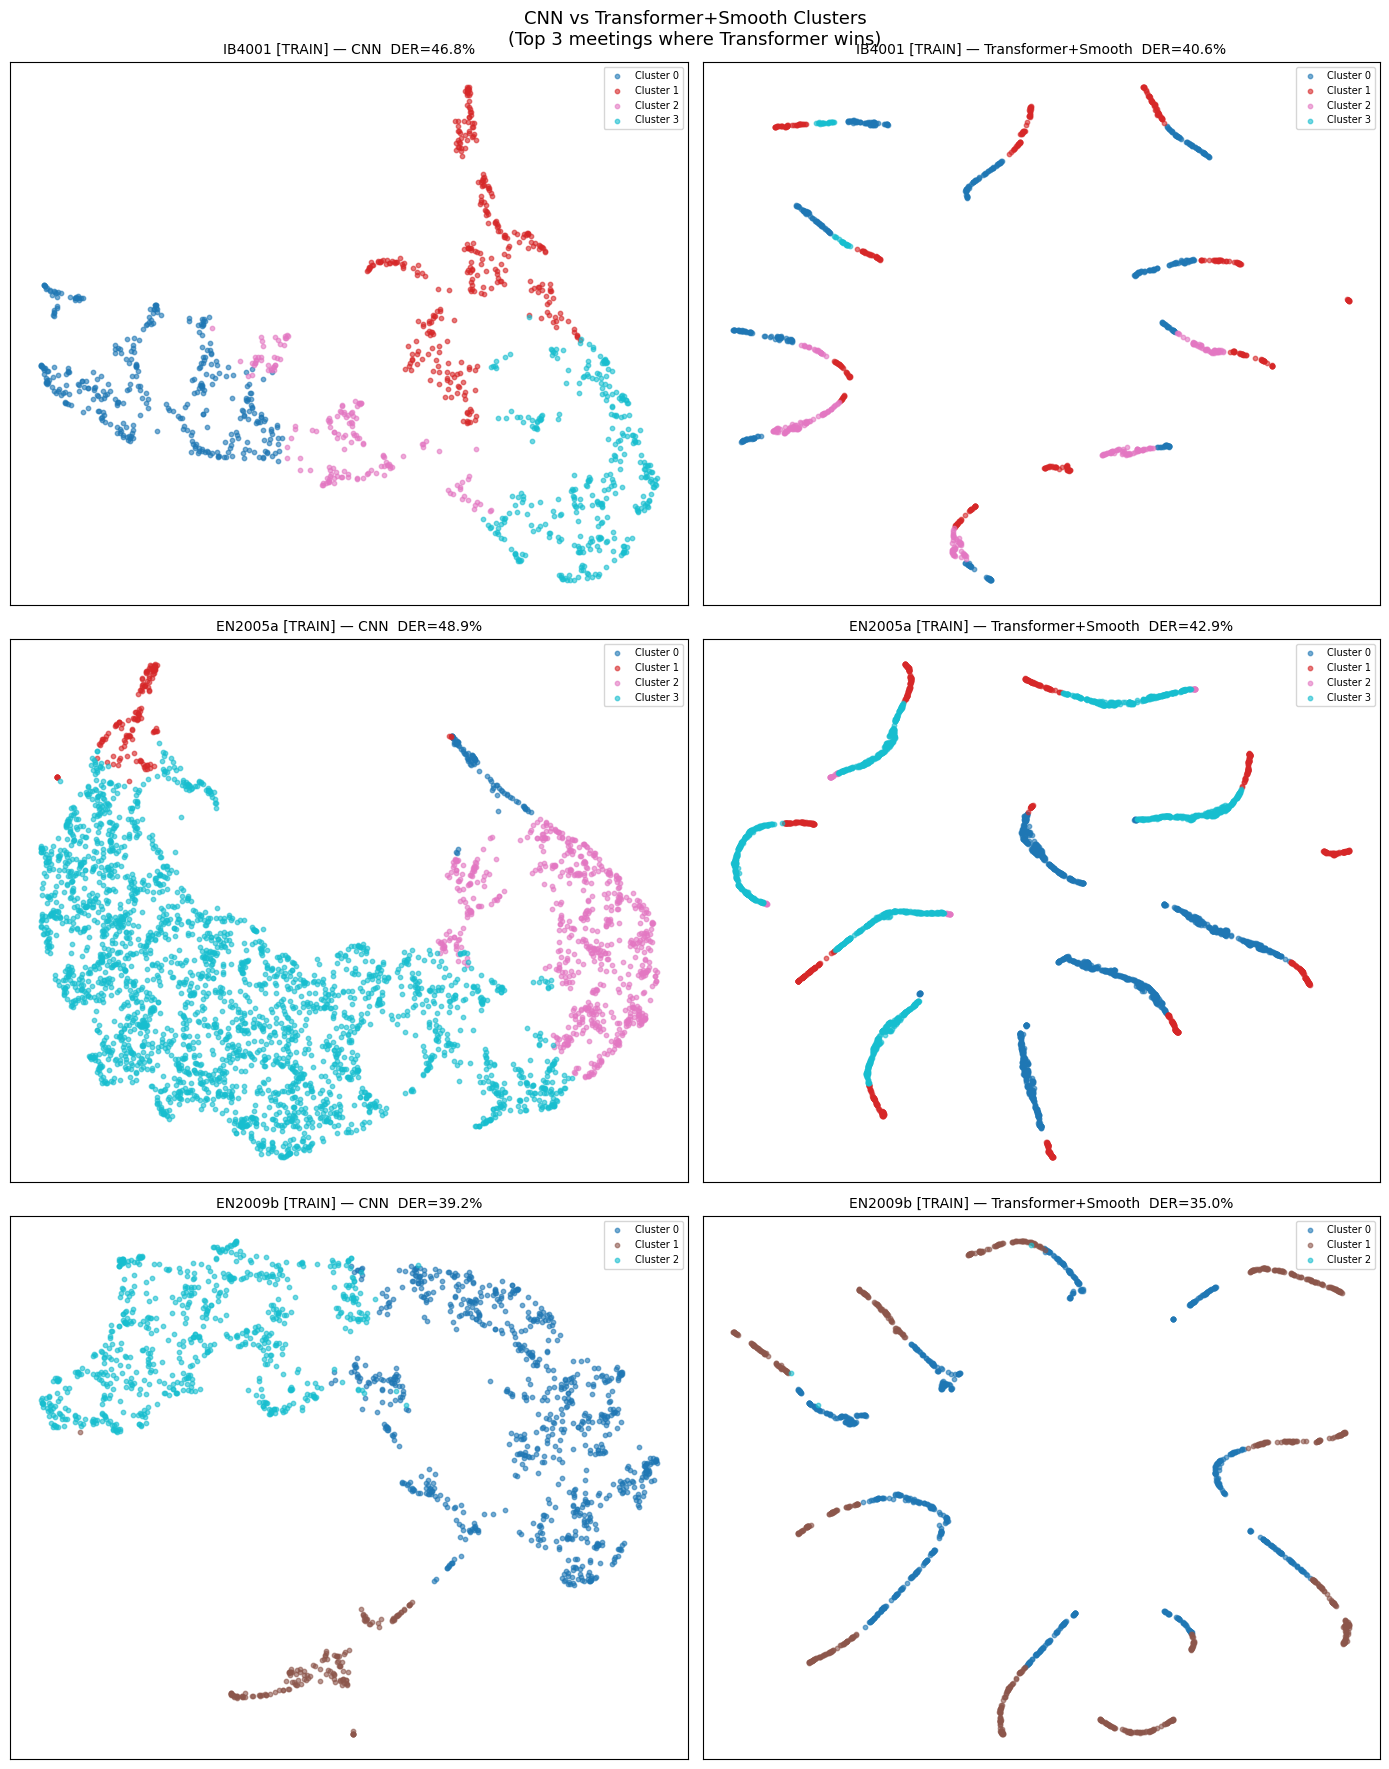

In [ ]:
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# find top 3 meetings where transformer+smooth beats CNN the most
df_smooth["improvement"] = df_smooth["der_cnn"] - df_smooth["der_smooth"]
top3 = df_smooth.nlargest(3, "improvement")["meeting"].tolist()

print("Top 3 meetings where Transformer+Smooth beats CNN:")
for m in top3:
    row = df_smooth[df_smooth["meeting"] == m].iloc[0]
    print(f"  {m}: CNN={row['der_cnn']*100:.1f}%  Trans+Smooth={row['der_smooth']*100:.1f}%  improvement={row['improvement']*100:.1f}%")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row_idx, meeting in enumerate(top3):
    true_labels = meeting_labels[meeting]
    trans_embs  = meeting_embeddings[meeting]
    cnn_embs    = cnn_meeting_embeddings[meeting]

    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    # smooth transformer embeddings
    smoothed = smooth_embeddings(trans_embs, window=5)

    # cluster both
    pred_cnn    = cluster_meeting(cnn_embs, n_true)
    pred_smooth = cluster_meeting(smoothed, n_true)

    proj_cnn    = reducer.fit_transform(cnn_embs)
    proj_smooth = reducer.fit_transform(smoothed)

    # color by predicted cluster
    colors = plt.cm.tab10(np.linspace(0, 1, n_true))

    #  CNN plot
    ax_cnn = axes[row_idx, 0]
    for c in range(n_true):
        mask = pred_cnn == c
        ax_cnn.scatter(proj_cnn[mask, 0], proj_cnn[mask, 1],
                       c=[colors[c]], s=10, alpha=0.6, label=f"Cluster {c}")

    der_cnn, _, _ = compute_der(true_labels, pred_cnn)
    split = "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")
    ax_cnn.set_title(f"{meeting} [{split}] — CNN  DER={der_cnn*100:.1f}%", fontsize=10)
    ax_cnn.set_xticks([]); ax_cnn.set_yticks([])
    ax_cnn.legend(fontsize=7, loc="upper right")

    # Transformer+Smooth plot
    ax_trans = axes[row_idx, 1]
    for c in range(n_true):
        mask = pred_smooth == c
        ax_trans.scatter(proj_smooth[mask, 0], proj_smooth[mask, 1],
                         c=[colors[c]], s=10, alpha=0.6, label=f"Cluster {c}")

    der_smooth, _, _ = compute_der(true_labels, pred_smooth)
    ax_trans.set_title(f"{meeting} [{split}] — Transformer+Smooth  DER={der_smooth*100:.1f}%", fontsize=10)
    ax_trans.set_xticks([]); ax_trans.set_yticks([])
    ax_trans.legend(fontsize=7, loc="upper right")

plt.suptitle("CNN vs Transformer+Smooth Clusters\n(Top 3 meetings where Transformer wins)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cnn_vs_transformer_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

Final Output


In [ ]:
def generate_clean_diarization(meeting, embeddings, true_labels,
                                n_speakers, hop_sec=1.5, smooth_window=5):
    smoothed = smooth_embeddings(embeddings, window=smooth_window)
    pred     = cluster_meeting(smoothed, n_speakers)

    subset   = df_emb[df_emb["meeting"] == meeting].sort_values("start_time").reset_index(drop=True)
    seq_len  = 10
    n_blocks = len(subset) // seq_len * seq_len
    subset   = subset.iloc[:n_blocks].reset_index(drop=True)

    # build frame level — one entry per window, no merging yet
    frames = []
    for i, (_, row) in enumerate(subset.iterrows()):
        frames.append({
            "start":   row["start_time"],
            "end":     row["end_time"],
            "cluster": pred[i],
            "true":    true_labels[i]
        })

    # convert overlapping windows to non-overlapping by taking
    # the midpoint of each window as its representative time
    # then assign speaker to each hop-sized slot
    if len(frames) == 0:
        return []

    total_dur = frames[-1]["end"]
    slot_dur  = hop_sec
    n_slots   = int(total_dur / slot_dur) + 1
    slot_spk  = [""] * n_slots

    for f in frames:
        mid_slot = int((f["start"] + f["end"]) / 2 / slot_dur)
        if 0 <= mid_slot < n_slots:
            slot_spk[mid_slot] = f["cluster"]

    # fill empty slots with nearest neighbor
    for i in range(len(slot_spk)):
        if slot_spk[i] == "":
            slot_spk[i] = slot_spk[i-1] if i > 0 else 0

    # merge consecutive same-speaker slots into segments
    segments = []
    seg_start = 0
    seg_spk   = slot_spk[0]

    for i in range(1, len(slot_spk)):
        if slot_spk[i] != seg_spk:
            segments.append({
                "start":   round(seg_start * slot_dur, 1),
                "end":     round(i * slot_dur, 1),
                "speaker": f"Speaker_{seg_spk}",
                "dur":     round((i - seg_start) * slot_dur, 1)
            })
            seg_start = i
            seg_spk   = slot_spk[i]

    segments.append({
        "start":   round(seg_start * slot_dur, 1),
        "end":     round(len(slot_spk) * slot_dur, 1),
        "speaker": f"Speaker_{seg_spk}",
        "dur":     round((len(slot_spk) - seg_start) * slot_dur, 1)
    })

    # remove very short segments (< 3s) — likely noise
    segments = [s for s in segments if s["dur"] >= 3.0]

    return segments


def print_clean_diarization(meeting, segments):
    print(f"\n{'='*50}")
    print(f"Diarization — {meeting}")
    print(f"{'='*50}")
    print(f"{'Start':>8} {'End':>8} {'Speaker':>12} {'Duration':>10}")
    print(f"{'-'*50}")
    for seg in segments:
        print(f"{seg['start']:>8.1f} {seg['end']:>8.1f} "
              f"{seg['speaker']:>12} {seg['dur']:>9.1f}s")
    print(f"{'='*50}")
    print(f"Total segments: {len(segments)}")


for meeting in test_meetings:
    true_labels  = meeting_labels[meeting]
    trans_embs   = meeting_embeddings[meeting]
    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    segments = generate_clean_diarization(
        meeting, trans_embs, true_labels, n_true
    )
    print_clean_diarization(meeting, segments)


Diarization — IS1000a
   Start      End      Speaker   Duration
--------------------------------------------------
     1.5      9.0    Speaker_1       7.5s
     9.0     15.0    Speaker_0       6.0s
    15.0     18.0    Speaker_2       3.0s
    18.0     24.0    Speaker_1       6.0s
    24.0     30.0    Speaker_0       6.0s
    30.0     33.0    Speaker_2       3.0s
    33.0     39.0    Speaker_1       6.0s
    42.0     45.0    Speaker_0       3.0s
    45.0     48.0    Speaker_2       3.0s
    48.0     54.0    Speaker_1       6.0s
    55.5     58.5    Speaker_3       3.0s
    60.0     63.0    Speaker_2       3.0s
    63.0     69.0    Speaker_1       6.0s
    70.5     75.0    Speaker_3       4.5s
    75.0     78.0    Speaker_2       3.0s
    78.0     82.5    Speaker_1       4.5s
    82.5     90.0    Speaker_3       7.5s
    90.0     93.0    Speaker_2       3.0s
    93.0     99.0    Speaker_1       6.0s
   102.0    105.0    Speaker_0       3.0s
   105.0    108.0    Speaker_2       3.0s
  

In [ ]:
def merge_short_segments(segments, min_dur=6.0):

    if len(segments) == 0:
        return segments

    merged = [segments[0].copy()]

    for seg in segments[1:]:
        if seg["dur"] < min_dur:
            # merge into previous
            merged[-1]["end"] = seg["end"]
            merged[-1]["dur"] = merged[-1]["end"] - merged[-1]["start"]
        else:
            # check if same speaker as previous — merge if so
            if seg["speaker"] == merged[-1]["speaker"]:
                merged[-1]["end"] = seg["end"]
                merged[-1]["dur"] = merged[-1]["end"] - merged[-1]["start"]
            else:
                merged.append(seg.copy())

    return merged


for meeting in test_meetings:
    true_labels   = meeting_labels[meeting]
    trans_embs    = meeting_embeddings[meeting]
    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    segments = generate_clean_diarization(meeting, trans_embs, true_labels, n_true)
    segments = merge_short_segments(segments, min_dur=6.0)
    print_clean_diarization(meeting, segments)


Diarization — IS1000a
   Start      End      Speaker   Duration
--------------------------------------------------
     1.5      9.0    Speaker_1       7.5s
     9.0     18.0    Speaker_0       9.0s
    18.0     24.0    Speaker_1       6.0s
    24.0     33.0    Speaker_0       9.0s
    33.0     82.5    Speaker_1      49.5s
    82.5     93.0    Speaker_3      10.5s
    93.0    114.0    Speaker_1      21.0s
   114.0    123.0    Speaker_0       9.0s
   123.0    157.5    Speaker_1      34.5s
   162.0    168.0    Speaker_0       6.0s
   168.0    174.0    Speaker_1       6.0s
   174.0    183.0    Speaker_0       9.0s
   183.0    217.5    Speaker_1      34.5s
   217.5    228.0    Speaker_3      10.5s
   228.0    234.0    Speaker_1       6.0s
   234.0    243.0    Speaker_0       9.0s
   243.0    249.0    Speaker_1       6.0s
   249.0    258.0    Speaker_0       9.0s
   258.0    264.0    Speaker_1       6.0s
   267.0    273.0    Speaker_0       6.0s
   273.0    279.0    Speaker_1       6.0s
  

Save output

In [ ]:
all_rows = []

for meeting in all_meetings:
    true_labels   = meeting_labels[meeting]
    trans_embs    = meeting_embeddings[meeting]
    true_speakers = [l for l in set(true_labels) if "silence" not in l]
    n_true        = len(true_speakers)

    segments = generate_clean_diarization(meeting, trans_embs, true_labels, n_true)
    segments = merge_short_segments(segments, min_dur=6.0)

    for seg in segments:
        all_rows.append({
            "meeting":  meeting,
            "start":    seg["start"],
            "end":      seg["end"],
            "speaker":  seg["speaker"],
            "duration": seg["dur"],
            "split":    "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")
        })

df_diarization = pd.DataFrame(all_rows)
df_diarization.to_csv("/content/drive/MyDrive/diarization_output.csv", index=False)

print(f"Saved {len(df_diarization)} segments to Drive")
print(df_diarization.head(10))

Saved 2033 segments to Drive
   meeting  start   end    speaker  duration  split
0  EN2001a    1.5   9.0  Speaker_4       7.5  TRAIN
1  EN2001a    9.0  18.0  Speaker_2       9.0  TRAIN
2  EN2001a   18.0  24.0  Speaker_4       6.0  TRAIN
3  EN2001a   24.0  30.0  Speaker_2       6.0  TRAIN
4  EN2001a   30.0  39.0  Speaker_1       9.0  TRAIN
5  EN2001a   39.0  48.0  Speaker_2       9.0  TRAIN
6  EN2001a   48.0  54.0  Speaker_4       6.0  TRAIN
7  EN2001a   54.0  63.0  Speaker_2       9.0  TRAIN
8  EN2001a   63.0  69.0  Speaker_4       6.0  TRAIN
9  EN2001a   69.0  75.0  Speaker_2       6.0  TRAIN


In [ ]:
torch.save({
    "transformer_state": transformer.state_dict(),
    "transformer_config": {
        "input_dim":       256,
        "nhead":           4,
        "num_layers":      2,
        "dim_feedforward": 512,
        "dropout":         0.3
    },
    "cnn_config": {
        "embedding_dim": 256
    },
    "pipeline_info": {
        "window_sec":    3.0,
        "context_sec":   30.0,
        "hop_sec":       15.0,
        "smooth_window": 5,
        "min_seg_dur":   6.0
    }
}, "/content/drive/MyDrive/diarization_pipeline.pth")

print("Pipeline saved to Drive")

Pipeline saved to Drive
